<a href="https://colab.research.google.com/github/leonardeugenia-hash/TGF2026/blob/main/datos1_spotify_pib_internet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carga de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# nos aseguramos de poder ver todas las columnas
pd.set_option("display.max_columns", None)

# leemos archivos que vamos a usar en este script
df_spotify = pd.read_csv("spotify_tfg_2010_2024.csv")
df_pib = pd.read_excel("pib_per_capita_2010_2024.xls", header=3)
df_internet = pd.read_excel("internt_access_2010_2024.xls", header=3)


df_internet.columns = df_internet.columns.astype(str).str.strip()
df_pib.columns = df_pib.columns.astype(str).str.strip()


print(f"Spotify:  {df_spotify.shape[0]} canciones, {df_spotify.shape[1]} columnas")
print(f"PIB:      {df_pib.shape}")
print(f"Internet: {df_internet.shape}")

df_spotify.head()


Spotify:  1185 canciones, 18 columnas
PIB:      (266, 69)
Internet: (266, 69)


,playlist_id,playlist_name,source_year,source_label,track_id,track_name,artist_id,artist_name,album_id,album_name,release_date,release_year,duration_ms,explicit,popularity,duration_sec,artist_popularity,artist_genres
0,0JeRXLk1SHPRlGLiHA8PpB,2010 españa - TFG EILH,2010,Top Hits 2010,2yc9sElleYDl3NXMZSgsRv,Blanco y Negro,3TLGNOdp1UWYMnV5XG9HkR,Malú,7popMaqBQ73NwM0Evpn16K,Guerra Fria,2010-05-08,2010,233666,0,58,233.666,60,"flamenco pop, flamenco"
1,0JeRXLk1SHPRlGLiHA8PpB,2010 españa - TFG EILH,2010,Top Hits 2010,7bp62Lo0nOBcfB70iUoibE,Barbie de extrarradio,1EXjXQpDx2pROygh8zvHs4,Melendi,1O2K1CtGy9oNUPkmOKLnAx,Volvamos a empezar (Deluxe edition),2010-10-29,2010,215946,0,65,215.946,73,"flamenco, flamenco pop"
2,0JeRXLk1SHPRlGLiHA8PpB,2010 españa - TFG EILH,2010,Top Hits 2010,4PHX6bpHDxiR9RGzAKWcyk,Cuando Me Enamoro,7qG3b048QCHVRO5Pv1T5lw,Enrique Iglesias,5JNhQFH8HMKQWP4SITzdoc,Euphoria,2010,2010,200586,0,78,200.586,78,"latin pop, latin"
3,0JeRXLk1SHPRlGLiHA8PpB,2010 españa - TFG EILH,2010,Top Hits 2010,33LvyB8v3LELoM4NKL2WKB,Mira la Vida,3AIPhNgeF9S1Kyg9Yy3UQW,Dani Martín,4rvQboX5D6Ky8fn96cRLcL,Pequeño,2010-10-26,2010,221013,0,46,221.013,63,NaN
4,0JeRXLk1SHPRlGLiHA8PpB,2010 españa - TFG EILH,2010,Top Hits 2010,75hfPTtNhiqUglKXIVOaju,Sonrisa,5YekZn3GGnPIURNA6RG124,Ana Torroja,01S3TDog2mZQlXFEneONwt,Sonrisa,2010-09-14,2010,259040,0,40,259.040,59,latin pop


Diagnostico del dataset de Spotify

In [16]:
print("=" * 55)
print("ESTRUCTURA GENERAL DE LOS DATOS DE SPOTIFY")
print("=" * 55)
print(f"Datos columnas (total {df_spotify.shape[1]} columnas):")

print(f"{'#':<5} {'Columna':<20} {'Nulos':<15} {'tipo'}")
print(f"{'---':<5} {'------':<20} {'----------':<15} {'-----'}")

for i, col in enumerate(df_spotify.columns):
    null_count = df_spotify[col].isnull().sum()
    dtype = df_spotify[col].dtype
    print(f"{i:<5} {col:<20} {null_count:<15} {dtype}")


print("\n" + "=" * 55)
print("DUPLICADOS")
print("=" * 55)
dup_total  = df_spotify.duplicated().sum()
dup_cancion = df_spotify.duplicated(subset=["track_id", "source_year"]).sum()
print(f"Filas completamente duplicadas:              {dup_total}")
print(f"Canciones duplicadas dentro del mismo año:   {dup_cancion}")

print("\n" + "=" * 55)
print("DISTRIBUCIÓN POR AÑO")
print("=" * 55)
print(df_spotify["source_year"].value_counts().sort_index())

# ── VARIABLES NUMÉRICAS ───────────────────────────────────────────────────────

if 'duration_min' not in df_spotify.columns:
    df_spotify['duration_min'] = df_spotify['duration_ms'] / 60000

cols_numericas = [
    col for col in df_spotify.select_dtypes(include='number').columns
    if col != 'duration_ms'
]

desc_num = df_spotify[cols_numericas].describe().T.round(2)
desc_num['count'] = desc_num['count'].astype(int)

cols_stat = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
year_rows  = ['source_year', 'release_year']
other_rows = desc_num.index.difference(year_rows)

desc_num.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .background_gradient(cmap='Reds', subset=['max']) \
    .background_gradient(cmap='Greens', subset=['min']) \
    .format(lambda v: f'{v:.0f}', subset=(year_rows, cols_stat)) \
    .format(lambda v: f'{int(v):d}', subset=(other_rows, ['count'])) \
    .format(lambda v: f'{int(v):d}', subset=(year_rows, ['count'])) \
    .format(lambda v: f'{v:.2f}', subset=(other_rows, cols_stat)) \
    .set_caption('Estadísticas descriptivas — variables numéricas') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4f8')]},
    ])

ESTRUCTURA GENERAL DE LOS DATOS DE SPOTIFY
Datos columnas (total 19 columnas):
#     Columna              Nulos           tipo
---   ------               ----------      -----
0     playlist_id          0               object
1     playlist_name        0               object
2     source_year          0               int64
3     source_label         0               object
4     track_id             0               object
5     track_name           0               object
6     artist_id            0               object
7     artist_name          0               object
8     album_id             0               object
9     album_name           0               object
10    release_date         0               object
11    release_year         0               int64
12    duration_ms          0               int64
13    explicit             0               int64
14    popularity           0               int64
15    duration_sec         0               float64
16    artist_popularity    0

,count,mean,std,min,25%,50%,75%,max
source_year,1185,2018,4,2010,2015,2018,2021,2024
release_year,1185,2018,4,1980,2015,2018,2021,2025
explicit,1185,0.14,0.34,0.00,0.00,0.00,0.00,1.00
popularity,1185,54.80,19.26,0.00,42.00,57.00,70.00,90.00
duration_sec,1185,213.31,40.92,105.84,187.44,209.92,233.07,519.29
artist_popularity,1185,66.52,16.30,2.00,55.00,69.00,80.00,100.00
duration_min,1185,3.56,0.68,1.76,3.12,3.50,3.88,8.65


In [17]:
# ── VARIABLES NO NUMÉRICAS ────────────────────────────────────────────────────
cols_categoricas = df_spotify.select_dtypes(exclude='number').columns.tolist()

desc_cat = df_spotify[cols_categoricas].describe(include='all').T[['count', 'unique', 'top', 'freq']].copy()
desc_cat['count'] = desc_cat['count'].astype(int)
desc_cat['freq']  = desc_cat['freq'].astype(int)

desc_cat.style \
    .background_gradient(cmap='Purples', subset=['unique']) \
    .background_gradient(cmap='Oranges', subset=['freq']) \
    .format({'count': '{:d}', 'freq': '{:,}'}) \
    .set_caption('Estadísticas descriptivas — variables categóricas') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4f8')]},
    ])

,count,unique,top,freq
playlist_id,1185,15,1d4QC8coOQPkxKKz1moFPZ,98
playlist_name,1185,15,2016 españa - TFG EILH,98
source_label,1185,15,Top Hits 2016,98
track_id,1185,1132,1m69ELEgE6k5ZWsap40ozt,3
track_name,1185,1105,París,3
artist_id,1185,464,4q3ewBCX7sLwd24euuV69X,22
artist_name,1185,464,Bad Bunny,22
album_id,1185,1000,4kS7bSuU0Jm9LYMosFU2x5,9
album_name,1185,987,MAÑANA SERÁ BONITO,9
release_date,1185,723,2013-01-01,14


Limpieza del dataset de Spotify

In [48]:
# copiamos para no podificar el original
df_spotify_clean = df_spotify.copy()

# eliminamos columnas innecesarias
cols_drop = [
    "playlist_id", "playlist_name", "artist_id",
    "album_id", "album_id", "duration_ms", "source_label"]
df_spotify_clean = df_spotify_clean.drop(columns=cols_drop)

# cambianos nombre a source_year
df_spotify_clean = df_spotify_clean.rename(columns={"source_year": "year"})

# cambiamos los tipos de variables
df_spotify_clean["year"]         = df_spotify_clean["year"].astype(int)
df_spotify_clean["release_year"] = pd.to_numeric(df_spotify_clean["release_year"], errors="coerce").astype("Int64")
df_spotify_clean["release_date"] = pd.to_datetime(df_spotify_clean["release_date"], errors="coerce")

# creamos variable: mes de lanzamiento
df_spotify_clean["release_month"] = df_spotify_clean["release_date"].dt.month

# creamos variable: antigüedad de la canción en el momento de entrar en la lista
df_spotify_clean['years_since_release'] = df_spotify_clean['year'] - df_spotify_clean['release_year']


# creamos variable: género principal (el primero de la lista)
# Convert artist_genres to string to handle potential non-string types, then split and take the first element.
# If artist_genres is NaN, str(NaN) becomes "nan", so we convert "nan" strings back to actual pd.NA.
df_spotify_clean["genre_group"] = df_spotify_clean["artist_genres"].astype(str).str.split(", ").str[0]
df_spotify_clean.loc[df_spotify_clean["genre_group"] == "nan", "genre_group"] = pd.NA

print("Columnas finales:", df_spotify_clean.columns.tolist())
print("\nShape:", df_spotify_clean.shape)
print("\nNulos restantes:")
print(df_spotify_clean.isnull().sum())

Columnas finales: ['year', 'track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'release_year', 'explicit', 'popularity', 'duration_sec', 'artist_popularity', 'artist_genres', 'duration_min', 'years_since_release', 'release_month', 'genre_group']

Shape: (1185, 16)

Nulos restantes:
year                     0
track_id                 0
track_name               0
artist_name              0
album_name               0
release_date            10
release_year             0
explicit                 0
popularity               0
duration_sec             0
artist_popularity        0
artist_genres          462
duration_min             0
years_since_release      0
release_month           10
genre_group            462
dtype: int64


Limpieza de nulos

In [49]:

nulos_fecha = df_spotify_clean[df_spotify_clean["release_date"].isna()][["year", "track_name", "artist_name"]]
print(f"Canciones sin fecha de lanzamiento ({len(nulos_fecha)} casos, {len(nulos_fecha)/len(df_spotify_clean)*100:.1f}%):")
print(nulos_fecha.to_string(index=False))
print("\n→ Decisión: se conservan como nulos.")

nulos_genres  = df_spotify_clean[df_spotify_clean["artist_genres"].isna()]
tiene_group   = nulos_genres["genre_group"].notna().sum()
sin_group     = nulos_genres["genre_group"].isna().sum()

print(f"\nNulos en artist_genres: {len(nulos_genres)}")
print(f"  → Con genre_group ya asignado:  {tiene_group}  ✓ (no es problema)")
print(f"  → Sin genre_group tampoco:      {sin_group}  (estos necesitan tratamiento)")

# Los que no tienen ninguna información de género → los marcamos como "unknown"
mask_sin_grupo = df_spotify_clean["artist_genres"].isna() & df_spotify_clean["genre_group"].isna()
df_spotify_clean.loc[mask_sin_grupo, "genre_group"] = "unknown"

print(f"\nCanciones marcadas como 'unknown': {mask_sin_grupo.sum()}")
print("\n→ artist_genres se conserva como NaN (texto libre, no entra en modelos).")
print("→ genre_group = 'unknown' para los sin información.")

print("\nDistribución final de genre_group:")
print(df_spotify_clean["genre_group"].value_counts())

Canciones sin fecha de lanzamiento (10 casos, 0.8%):
 year                               track_name          artist_name
 2010                        Cuando Me Enamoro     Enrique Iglesias
 2010             Chiquitita - Spanish Version                 ABBA
 2010                                I Like It     Enrique Iglesias
 2011 La Quiero a Morir (feat. Alejandro Sanz)       Jarabe De Palo
 2011                           Feel The Magic              Pastora
 2011                          El Viejo Verano            El Barrio
 2012                                    Tanto        Pablo Alborán
 2012   Dónde está el amor (feat. Jesse & Joy)        Pablo Alborán
 2018                    BEBE (feat. Anuel AA)              6ix9ine
 2024                                    Rosas La Oreja de Van Gogh

→ Decisión: se conservan como nulos.

Nulos en artist_genres: 462
  → Con genre_group ya asignado:  0  ✓ (no es problema)
  → Sin genre_group tampoco:      462  (estos necesitan tratamiento)

Cancio

Comprobamos que las modificaciones se hicieron correctamente

In [50]:
print("\nNulos restantes:")
print(df_spotify_clean.isnull().sum())
print(df_spotify_clean.shape)


Nulos restantes:
year                     0
track_id                 0
track_name               0
artist_name              0
album_name               0
release_date            10
release_year             0
explicit                 0
popularity               0
duration_sec             0
artist_popularity        0
artist_genres          462
duration_min             0
years_since_release      0
release_month           10
genre_group              0
dtype: int64
(1185, 16)


Outliers por canción

OUTLIERS A NIVEL DE CANCIÓN (método IQR)

Canciones con duración atípica (31 casos):


,Año,Canción,Artista,Duración (seg),Duración (min)
1,2010,Chiquitita - Spanish Version,ABBA,333.1,5.55
2,2011,Si te vas...,Extremoduro,516.7,8.61
3,2011,Sick of Love,Robert Ramirez,326.4,5.44
4,2013,No Dejes De Soñar,Manuel Carrasco,319.6,5.33
5,2013,El camino de las utopías,Extremoduro,450.5,7.51
6,2014,Mi Problema,Ismael Serrano,366.0,6.10
7,2015,Slowly,Natalia Lafourcade,336.8,5.61
8,2015,A Que No Me Dejas,Alejandro Sanz,311.2,5.19
9,2015,Llévame Muy Lejos,Amaral,336.7,5.61
10,2015,Los Abrazos Rotos (with Alex Ubago),Amaia Montero,305.9,5.10




         Variable  Límite inferior  Límite superior  N outliers  % outliers
     duration_sec           118.98           301.52          31        2.62
       popularity             0.00           112.00           0        0.00
artist_popularity            17.50           117.50           5        0.42

→ Se conservan todos los outliers para no sesgar las tendencias temporales.

Nota: 'years_since_release' excluida del análisis IQR por distribución degenerada.
Se detectaron 65 canciones con antigüedad negativa (release_year > year), tratadas como datos anómalos.


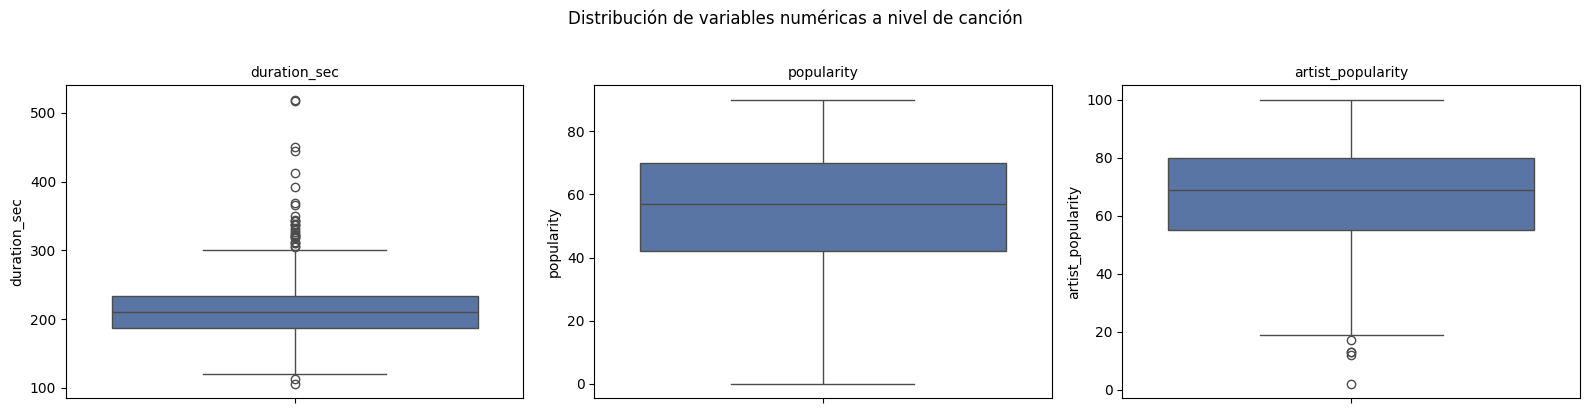

In [54]:
cols_numericas_cancion = ["duration_sec", "popularity", "artist_popularity"]

print("=" * 55)
print("OUTLIERS A NIVEL DE CANCIÓN (método IQR)")
print("=" * 55)

outlier_resumen = []
for col in cols_numericas_cancion:
    Q1  = df_spotify_clean[col].quantile(0.25)
    Q3  = df_spotify_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_spotify_clean[col] < lower) | (df_spotify_clean[col] > upper)).sum()
    pct   = n_out / len(df_spotify_clean) * 100
    outlier_resumen.append({"Variable": col, "Límite inferior": round(lower, 2),
                             "Límite superior": round(upper, 2),
                             "N outliers": n_out, "% outliers": round(pct, 2)})

    # Mostramos las canciones outliers en duración para revisión manual
    if col == "duration_sec":
        outliers_dur = df_spotify_clean[
            (df_spotify_clean[col] < lower) | (df_spotify_clean[col] > upper)
        ].copy()

        if len(outliers_dur) > 0:
            print(f"\nCanciones con duración atípica ({n_out} casos):")

            tabla_dur = outliers_dur[["year", "track_name", "artist_name", "duration_sec", "duration_min"]].sort_values("year").reset_index(drop=True)

            tabla_dur["duration_min"] = tabla_dur["duration_min"].round(2)
            tabla_dur["duration_sec"] = tabla_dur["duration_sec"].round(1)
            tabla_dur.index += 1  # índice desde 1

            tabla_dur.columns = ["Año", "Canción", "Artista", "Duración (seg)", "Duración (min)"]

            display(
                tabla_dur.style
                .background_gradient(cmap='Oranges', subset=['Duración (min)'])
                .set_caption(f'Canciones con duración atípica — {n_out} casos (método IQR)')
                .set_table_styles([
                    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left')]},
                    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '12px')]},
                    {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'center')]},
                    {'selector': 'tr:hover td', 'props': [('background-color', '#f0f4f8')]},
                ])
                .format({"Duración (seg)": "{:.1f}", "Duración (min)": "{:.2f}", "Año": "{:.0f}"})

            )


df_outliers = pd.DataFrame(outlier_resumen)
print("\n")
print(df_outliers.to_string(index=False))
print("\n→ Se conservan todos los outliers para no sesgar las tendencias temporales.")

n_negativos = (df_spotify_clean['years_since_release'] < 0).sum()
print(f"\nNota: 'years_since_release' excluida del análisis IQR por distribución degenerada.")
print(f"Se detectaron {n_negativos} canciones con antigüedad negativa (release_year > year), tratadas como datos anómalos.")

# Visualización de outliers a nivel de canción
fig, axes = plt.subplots(1, len(cols_numericas_cancion), figsize=(16, 4))
for ax, col in zip(axes, cols_numericas_cancion):
    sns.boxplot(y=df_spotify_clean[col], ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.suptitle("Distribución de variables numéricas a nivel de canción", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


Análisis exploratorio a nivel de canción

Distribución de genre_group:
genre_group
unknown              462
reggaeton            203
flamenco              97
latin pop             80
indie                 29
                    ... 
reggaeton mexa         1
corridos tumbados      1
cuarteto               1
k-pop                  1
techengue              1
Name: count, Length: 61, dtype: int64

Porcentaje de canciones explícitas por año:
year
2010     0.0
2011     2.0
2012     0.0
2013     0.0
2014     0.0
2015     2.1
2016     5.1
2017     3.1
2018     6.4
2019    17.7
2020    13.3
2021    22.1
2022    34.4
2023    37.9
2024    36.0
Name: explicit, dtype: float64


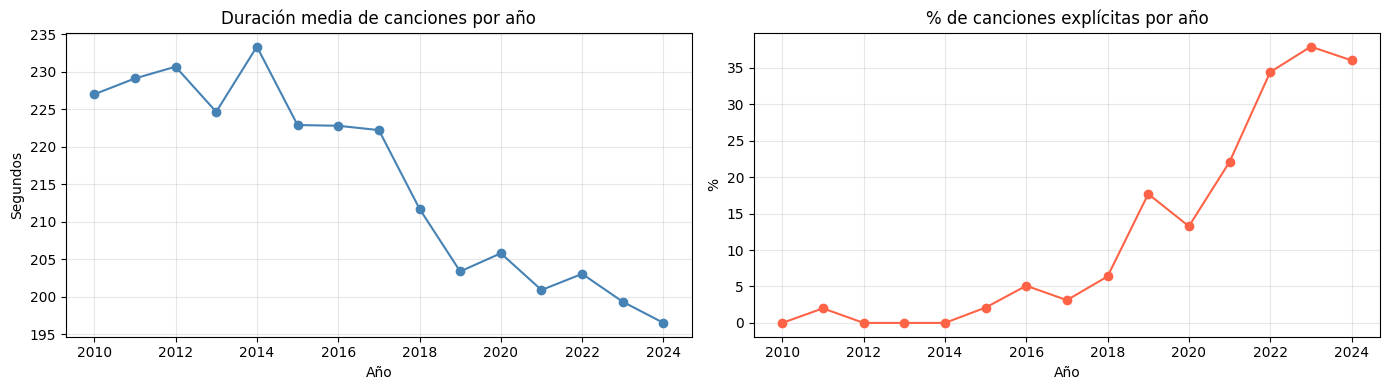

/tmp/ipykernel_1061/909467714.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


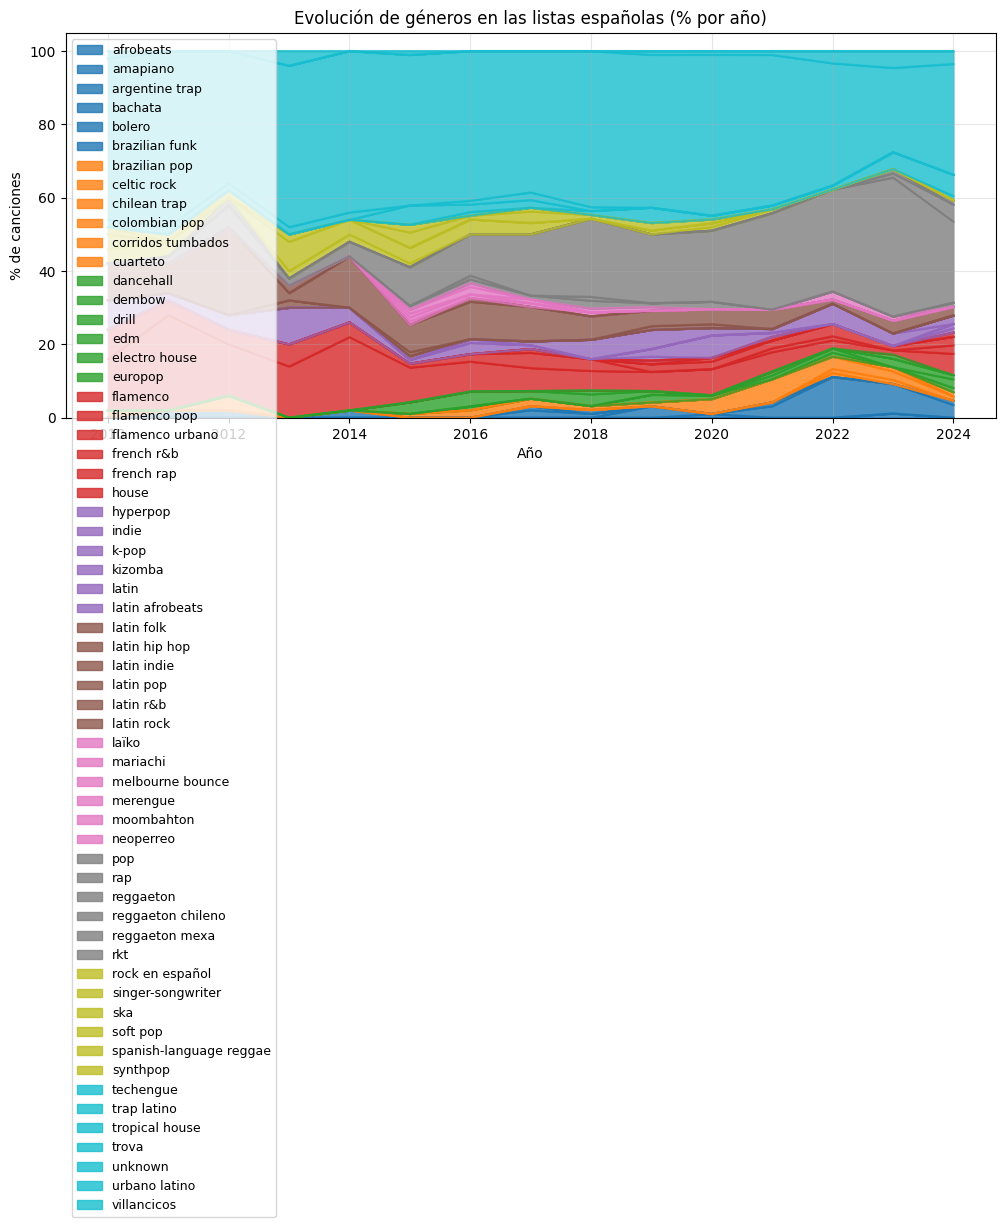

In [55]:
# Distribución de géneros
print("Distribución de genre_group:")
print(df_spotify_clean["genre_group"].value_counts())
print("\nPorcentaje de canciones explícitas por año:")
print(df_spotify_clean.groupby("year")["explicit"].mean().round(3) * 100)

# Evolución de la duración media de las canciones año a año (antes de agregar)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_spotify_clean.groupby("year")["duration_sec"].mean().plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("Duración media de canciones por año")
axes[0].set_ylabel("Segundos")
axes[0].set_xlabel("Año")
axes[0].grid(alpha=0.3)

df_spotify_clean.groupby("year")["explicit"].mean().mul(100).plot(ax=axes[1], marker="o", color="tomato")
axes[1].set_title("% de canciones explícitas por año")
axes[1].set_ylabel("%")
axes[1].set_xlabel("Año")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evolución de géneros a lo largo del tiempo
genre_year = df_spotify_clean.groupby(["year", "genre_group"]).size().unstack(fill_value=0)
genre_year_pct = genre_year.div(genre_year.sum(axis=1), axis=0) * 100

genre_year_pct.plot(kind="area", stacked=True, figsize=(12, 5), colormap="tab10", alpha=0.8)
plt.title("Evolución de géneros en las listas españolas (% por año)")
plt.ylabel("% de canciones")
plt.xlabel("Año")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Agregamos por año para poder analizar correctamente

In [56]:
# Agregaciones numéricas principales
df_year = df_spotify_clean.groupby("year").agg(
    avg_duration         = ("duration_sec",      "mean"),
    avg_popularity       = ("popularity",         "mean"),
    std_popularity       = ("popularity",         "std"),
    avg_artist_popularity= ("artist_popularity",  "mean"),
    explicit_ratio       = ("explicit",            "mean"),
    n_songs              = ("track_name",          "count"),
    n_unique_artists     = ("artist_name",         "nunique"),  # diversidad de artistas
    avg_years_since_rel  = ("years_since_release", "mean"),     # antigüedad media de las canciones
).reset_index()

# Añadimos el género dominante de cada año
genre_dominante = df_spotify_clean.groupby("year")["genre_group"].agg(
    lambda x: x.value_counts().idxmax()
).reset_index().rename(columns={"genre_group": "dominant_genre"})

# Añadimos % de cada género por año (columnas separadas)
genre_pct = df_spotify_clean.groupby(["year", "genre_group"]).size().unstack(fill_value=0)
genre_pct = genre_pct.div(genre_pct.sum(axis=1), axis=0).round(4)
genre_pct.columns = [f"pct_{g}" for g in genre_pct.columns]
genre_pct = genre_pct.reset_index()

# Unimos todo
df_year = df_year.merge(genre_dominante, on="year", how="left")
df_year = df_year.merge(genre_pct, on="year", how="left")

print("Dataset anual shape:", df_year.shape)
with pd.option_context('display.max_rows', None):
    display(df_year)

Dataset anual shape: (15, 71)


,year,avg_duration,avg_popularity,std_popularity,avg_artist_popularity,explicit_ratio,n_songs,n_unique_artists,avg_years_since_rel,dominant_genre,pct_afrobeats,pct_amapiano,pct_argentine trap,pct_bachata,pct_bolero,pct_brazilian funk,pct_brazilian pop,pct_celtic rock,pct_chilean trap,pct_colombian pop,pct_corridos tumbados,pct_cuarteto,pct_dancehall,pct_dembow,pct_drill,pct_edm,pct_electro house,pct_europop,pct_flamenco,pct_flamenco pop,pct_flamenco urbano,pct_french r&b,pct_french rap,pct_house,pct_hyperpop,pct_indie,pct_k-pop,pct_kizomba,pct_latin,pct_latin afrobeats,pct_latin folk,pct_latin hip hop,pct_latin indie,pct_latin pop,pct_latin r&b,pct_latin rock,pct_laïko,pct_mariachi,pct_melbourne bounce,pct_merengue,pct_moombahton,pct_neoperreo,pct_pop,pct_rap,pct_reggaeton,pct_reggaeton chileno,pct_reggaeton mexa,pct_rkt,pct_rock en español,pct_singer-songwriter,pct_ska,pct_soft pop,pct_spanish-language reggae,pct_synthpop,pct_techengue,pct_trap latino,pct_tropical house,pct_trova,pct_unknown,pct_urbano latino,pct_villancicos
0,2010,226.999240,41.520000,16.423279,54.240000,0.000000,50,42,0.56,unknown,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.02,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1400,0.0800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0800,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000,0.1000,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0400,0.0400,0.00,0.0000,0.0200,0.00,0.0000,0.0000,0.0000,0.0200,0.4400,0.0000,0.0200
1,2011,229.118400,37.200000,17.487021,51.420000,0.020000,50,41,-0.14,unknown,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2600,0.0400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000,0.0800,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.0000,0.0400,0.0000,0.00,0.0000,0.0000,0.02,0.0000,0.0000,0.0000,0.0200,0.4800,0.0000,0.0000
2,2012,230.686540,43.460000,17.881937,57.260000,0.000000,50,38,-0.16,unknown,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.00,0.0000,0.0400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1400,0.0400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0400,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000,0.2400,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0600,0.0000,0.0000,0.0200,0.0000,0.0000,0.00,0.0000,0.0200,0.00,0.0000,0.0000,0.0000,0.0200,0.3600,0.0000,0.0000
3,2013,224.661920,40.280000,14.255740,54.000000,0.000000,50,40,-0.1,unknown,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1400,0.0600,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,0.02,0.0000,0.0200,0.0000,0.02,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.0000,0.0200,0.0800,0.02,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,0.0200,0.4400,0.0000,0.0400
4,2014,233.362780,43.240000,16.213575,57.220000,0.000000,50,42,-0.02,unknown,0.0000,0.0000,0.0000,0.0000,0.0200,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2000,0.0400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0400,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000,0.1400,0.0000,0.00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0400,0.0000,0.0000,0.0000,0.0200,0.0400,0.00,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,0.0200,0.4400,0.0000,0.0000
5,2015,222.897716,54.221053,20.676937,64.936842,0.021053,95,85,-0.242105,unknown,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0316,0.0000,0.0000,0.0947,0.0105,0.0000,0.0000,0.0000,0.0000,0.0000,0.0105,0.0000,0.0000,0.0000,0.0000,0.0105,0.00,0.0105,0.0737,0.0000,0.00,0.0000,0.0105,0.0105,0.0105,0.0105,0.0000,0.0105,0.0000,0.1053,0.0000,0.0000,0.0000,0.0105,0.0421,0.00,0.0421,0.0211,0.00,0.0000,0.0000,0.0526,0.0000,0.4105,0.0000

Limpieza de los datos del PIB

In [57]:

# filtramos por España
df_spotify_pib = df_pib[df_pib["Country Name"].astype(str).str.strip() == "España"].copy()

print("Filas de España:", df_spotify_pib.shape)

# eliminamos columnas descriptivas
df_spotify_pib = df_spotify_pib.drop(columns=[
    "Country Name",
    "Country Code",
    "Indicator Name",
    "Indicator Code"
])

# usamos mismo formato que df_year (una fila por año)
df_spotify_pib = df_spotify_pib.melt(var_name="year", value_name="pib_per_capita")

# convertimos tipos
df_spotify_pib["year"] = pd.to_numeric(df_spotify_pib["year"], errors="coerce")
df_spotify_pib["pib_per_capita"] = pd.to_numeric(df_spotify_pib["pib_per_capita"], errors="coerce")

# filtramos por años del TFG (df_year)
df_spotify_pib = df_spotify_pib[(df_spotify_pib["year"] >= 2010) & (df_spotify_pib["year"] <= 2024)]

# eliminamos nulos
df_spotify_pib = df_spotify_pib.dropna().reset_index(drop=True)

print(df_spotify_pib.head())
print(sorted(df_spotify_pib["year"].unique().tolist()))
print(df_spotify_pib.isnull().sum())


Filas de España: (1, 69)
   year  pib_per_capita
0  2010    30658.742228
1  2011    31824.621913
2  2012    28456.443815
3  2013    29228.846560
4  2014    29707.765509
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
year              0
pib_per_capita    0
dtype: int64


Limpieza de los datos de acceso a internet

In [58]:
# filtramos por españa
df_spotify_internet = df_internet[df_internet["Country Name"].astype(str).str.strip() == "España"].copy()

print("Filas de España:", df_spotify_internet.shape)

# eliminamos columnas descriptivas
df_spotify_internet = df_spotify_internet.drop(columns=[
    "Country Name",
    "Country Code",
    "Indicator Name",
    "Indicator Code"
])

# usamos mismo formato que df_year (una fila por año)
df_spotify_internet = df_spotify_internet.melt(var_name="year", value_name="internet_access")

# convertimos tipos
df_spotify_internet["year"] = pd.to_numeric(df_spotify_internet["year"], errors="coerce")
df_spotify_internet["internet_access"] = pd.to_numeric(df_spotify_internet["internet_access"], errors="coerce")

# filtramos por años del TFG (df_year)
df_spotify_internet = df_spotify_internet[(df_spotify_internet["year"] >= 2010) & (df_spotify_internet["year"] <= 2024)]

# eliminamos nulos
df_spotify_internet = df_spotify_internet.dropna().reset_index(drop=True)

print(df_spotify_internet.head())
print(df_spotify_internet.shape)
print(sorted(df_spotify_internet["year"].unique().tolist()))
print(df_spotify_internet.isnull().sum())

Filas de España: (1, 69)
   year  internet_access
0  2010          65.8000
1  2011          67.0900
2  2012          69.8100
3  2013          71.6350
4  2014          76.1867
(15, 2)
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
year               0
internet_access    0
dtype: int64


Unimos los tres datsets

In [59]:
# unimos los dos datasets

# Start with the aggregated spotify data (df_year)
df_spotify_year = df_year.copy()

# Ensure 'year' column is integer type in df_spotify_pib for merging
df_spotify_pib["year"] = pd.to_numeric(df_spotify_pib["year"], errors="coerce").astype(int)

# Merge PIB data
# The drop is not strictly necessary if pib_per_capita is not in df_spotify_year yet,
# but keeping it with errors='ignore' is safe.
df_spotify_year = df_spotify_year.drop(columns=["pib_per_capita"], errors="ignore")
df_spotify_year = df_spotify_year.merge(df_spotify_pib, on="year", how="left")

# Ensure 'year' column is integer type in df_spotify_internet for merging
df_spotify_internet["year"] = pd.to_numeric(df_spotify_internet["year"], errors="coerce").astype(int)

# Merge internet access data
df_spotify_year = df_spotify_year.drop(columns=["internet_access"], errors="ignore")
df_spotify_year = df_spotify_year.merge(df_spotify_internet, on="year", how="left")

print(df_spotify_year.head())
print(df_spotify_year.isnull().sum())

   year  avg_duration  avg_popularity  std_popularity  avg_artist_popularity  \
0  2010     226.99924           41.52       16.423279                  54.24   
1  2011     229.11840           37.20       17.487021                  51.42   
2  2012     230.68654           43.46       17.881937                  57.26   
3  2013     224.66192           40.28       14.255740                  54.00   
4  2014     233.36278           43.24       16.213575                  57.22   

   explicit_ratio  n_songs  n_unique_artists  avg_years_since_rel  \
0            0.00       50                42                 0.56   
1            0.02       50                41                -0.14   
2            0.00       50                38                -0.16   
3            0.00       50                40                 -0.1   
4            0.00       50                42                -0.02   

  dominant_genre  pct_afrobeats  pct_amapiano  pct_argentine trap  \
0        unknown            0.0    

Comprobaciones finales

In [60]:
# validamos el dataset final
print(df_spotify_year.info())
print(df_spotify_year.describe())
print(df_spotify_year.isnull().sum())

# comprobamos los años
print("Año mínimo:", df_spotify_year["year"].min())
print("Año máximo:", df_spotify_year["year"].max())
print("Número de filas:", len(df_spotify_year))
print("Años:", sorted(df_spotify_year["year"].tolist()))

# ordenamos el dataset final por año
df_spotify_year = df_spotify_year.sort_values("year").reset_index(drop=True)
df_spotify_year.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 73 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         15 non-null     int64  
 1   avg_duration                 15 non-null     float64
 2   avg_popularity               15 non-null     float64
 3   std_popularity               15 non-null     float64
 4   avg_artist_popularity        15 non-null     float64
 5   explicit_ratio               15 non-null     float64
 6   n_songs                      15 non-null     int64  
 7   n_unique_artists             15 non-null     int64  
 8   avg_years_since_rel          15 non-null     Float64
 9   dominant_genre               15 non-null     object 
 10  pct_afrobeats                15 non-null     float64
 11  pct_amapiano                 15 non-null     float64
 12  pct_argentine trap           15 non-null     float64
 13  pct_bachata           

,year,avg_duration,avg_popularity,std_popularity,avg_artist_popularity,explicit_ratio,n_songs,n_unique_artists,avg_years_since_rel,dominant_genre,pct_afrobeats,pct_amapiano,pct_argentine trap,pct_bachata,pct_bolero,pct_brazilian funk,pct_brazilian pop,pct_celtic rock,pct_chilean trap,pct_colombian pop,pct_corridos tumbados,pct_cuarteto,pct_dancehall,pct_dembow,pct_drill,pct_edm,pct_electro house,pct_europop,pct_flamenco,pct_flamenco pop,pct_flamenco urbano,pct_french r&b,pct_french rap,pct_house,pct_hyperpop,pct_indie,pct_k-pop,pct_kizomba,pct_latin,pct_latin afrobeats,pct_latin folk,pct_latin hip hop,pct_latin indie,pct_latin pop,pct_latin r&b,pct_latin rock,pct_laïko,pct_mariachi,pct_melbourne bounce,pct_merengue,pct_moombahton,pct_neoperreo,pct_pop,pct_rap,pct_reggaeton,pct_reggaeton chileno,pct_reggaeton mexa,pct_rkt,pct_rock en español,pct_singer-songwriter,pct_ska,pct_soft pop,pct_spanish-language reggae,pct_synthpop,pct_techengue,pct_trap latino,pct_tropical house,pct_trova,pct_unknown,pct_urbano latino,pct_villancicos,pib_per_capita,internet_access
0,2010,226.99924,41.52,16.423279,54.24,0.00,50,42,0.56,unknown,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.02,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.08,0.0,0.0,0.0,0.0,0.0,0.08,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.10,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.04,0.04,0.00,0.0,0.02,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.02,30658.742228,65.8000
1,2011,229.11840,37.20,17.487021,51.42,0.02,50,41,-0.14,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.26,0.04,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.08,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.04,0.00,0.00,0.0,0.00,0.02,0.0,0.0,0.0,0.02,0.48,0.0,0.00,31824.621913,67.0900
2,2012,230.68654,43.46,17.881937,57.26,0.00,50,38,-0.16,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.04,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.24,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.06,0.0,0.0,0.02,0.00,0.00,0.00,0.0,0.02,0.00,0.0,0.0,0.0,0.02,0.36,0.0,0.00,28456.443815,69.8100
3,2013,224.66192,40.28,14.255740,54.00,0.00,50,40,-0.1,unknown,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.14,0.06,0.0,0.0,0.0,0.0,0.0,0.10,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.02,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.02,0.08,0.02,0.0,0.00,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.04,29228.846560,71.6350
4,2014,233.36278,43.24,16.213575,57.22,0.00,50,42,-0.02,unknown,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.20,0.04,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.14,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.04,0.0,0.0,0.00,0.02,0.04,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.02,0.44,0.0,0.00,29707.765509,76.1867


Analisis exploratorio del dataset anual

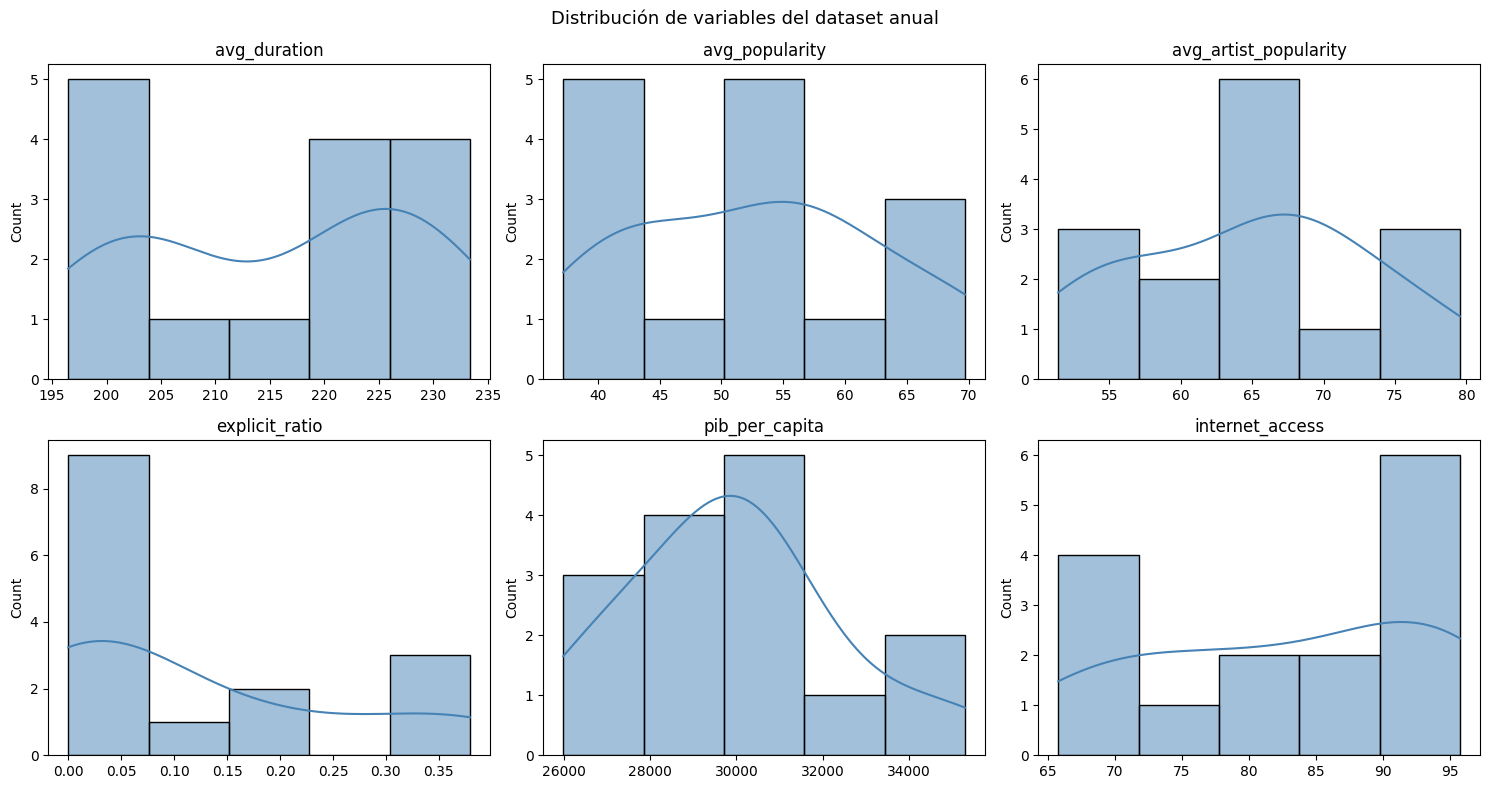

In [61]:
cols_plot = ["avg_duration", "avg_popularity", "avg_artist_popularity",
             "explicit_ratio", "pib_per_capita", "internet_access"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, cols_plot):
    sns.histplot(df_spotify_year[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distribución de variables del dataset anual", fontsize=13)
plt.tight_layout()
plt.show()

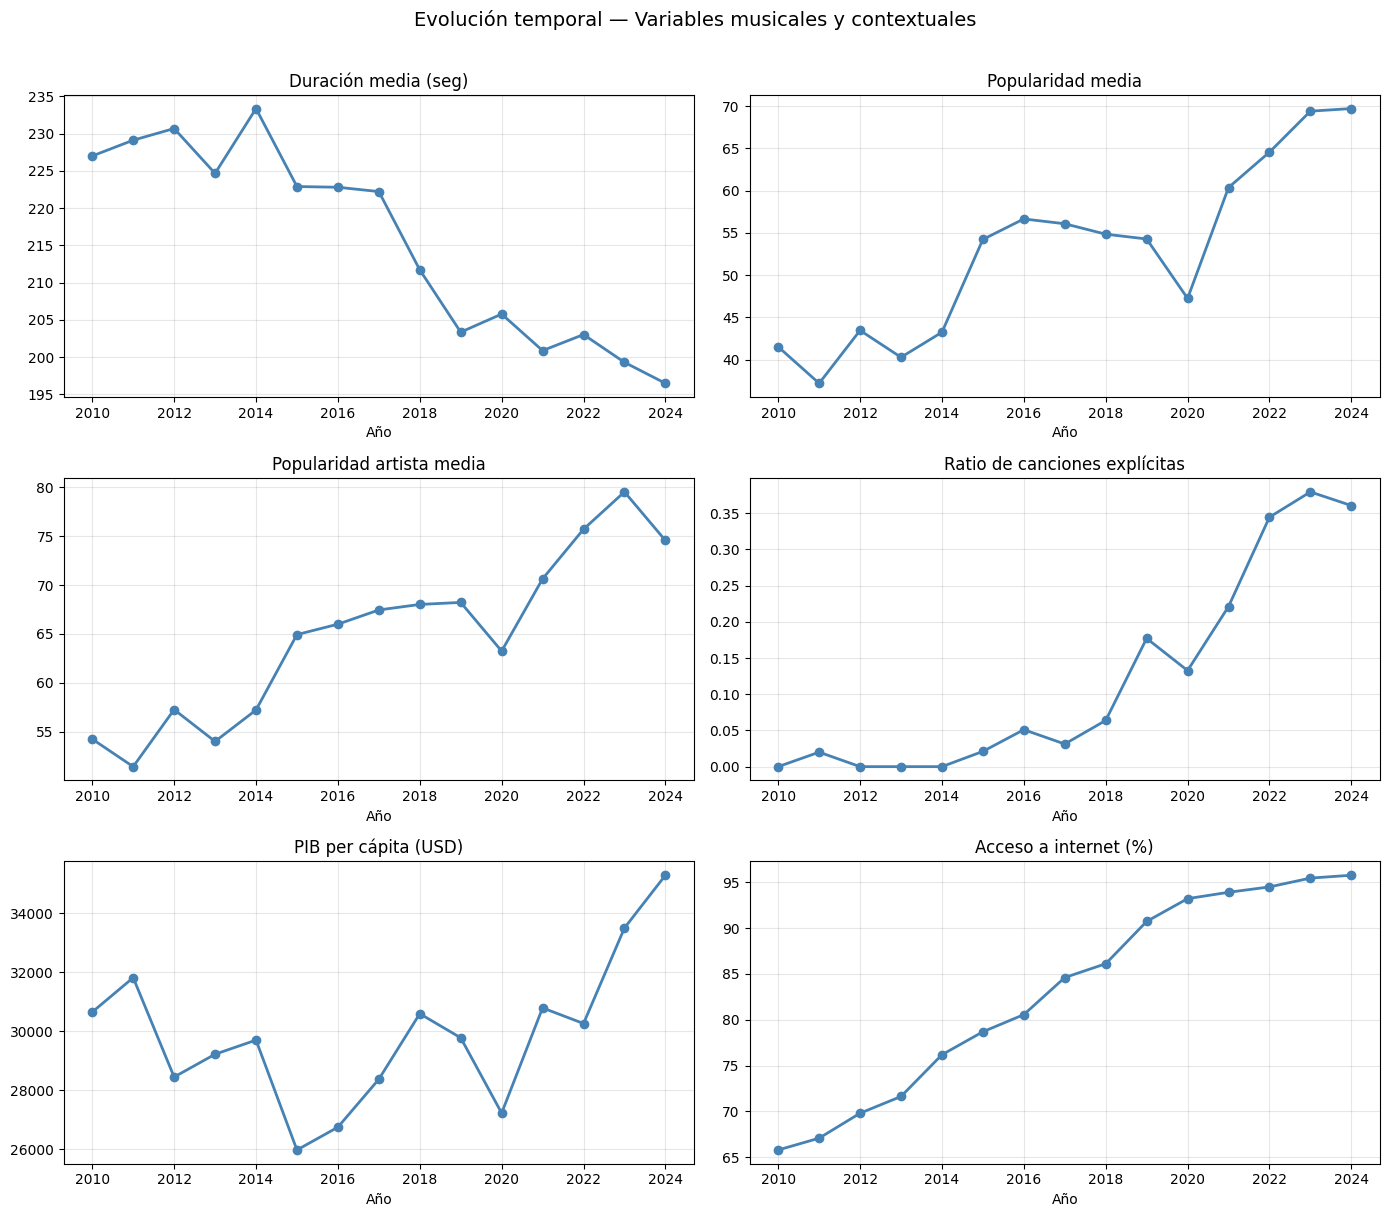

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

variables_evo = [
    ("avg_duration",          "Duración media (seg)"),
    ("avg_popularity",        "Popularidad media"),
    ("avg_artist_popularity", "Popularidad artista media"),
    ("explicit_ratio",        "Ratio de canciones explícitas"),
    ("pib_per_capita",        "PIB per cápita (USD)"),
    ("internet_access",       "Acceso a internet (%)"),
]

for ax, (col, label) in zip(axes, variables_evo):
    ax.plot(df_spotify_year["year"], df_spotify_year[col], marker="o", linewidth=2, color="steelblue")
    ax.set_title(label)
    ax.set_xlabel("Año")
    ax.grid(alpha=0.3)

plt.suptitle("Evolución temporal — Variables musicales y contextuales", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

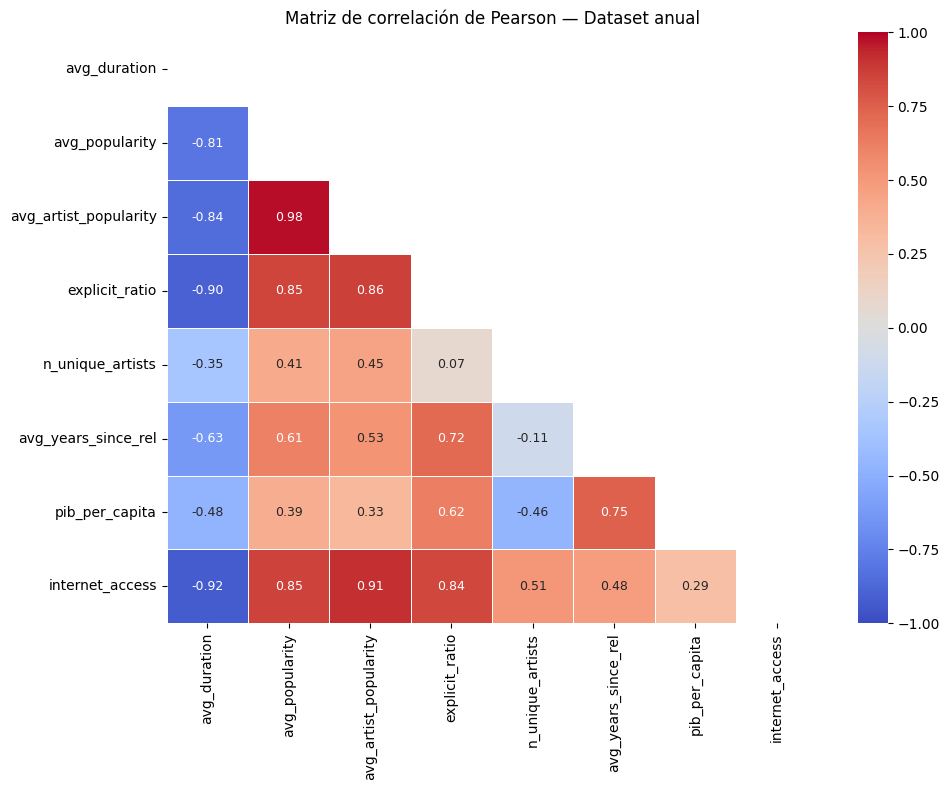


Correlaciones con avg_popularity (ordenadas):
avg_artist_popularity    0.979
internet_access          0.854
explicit_ratio           0.850
avg_duration            -0.806
avg_years_since_rel      0.611
n_unique_artists         0.409
pib_per_capita           0.391
Name: avg_popularity, dtype: float64


In [ ]:
cols_corr = ["avg_duration", "avg_popularity", "avg_artist_popularity",
             "explicit_ratio", "n_unique_artists", "avg_years_since_rel",
             "pib_per_capita", "internet_access"]

corr_matrix = df_spotify_year[cols_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 9})
plt.title("Matriz de correlación de Pearson — Dataset anual", fontsize=12)
plt.tight_layout()
plt.show()

# Correlaciones más fuertes con popularidad
print("\nCorrelaciones con avg_popularity (ordenadas):")
print(corr_matrix["avg_popularity"].drop("avg_popularity").sort_values(key=abs, ascending=False).round(3))

In [62]:
cols_adf = ["avg_duration", "avg_popularity", "avg_artist_popularity",
            "explicit_ratio", "pib_per_capita", "internet_access"]

print("=" * 65)
print("TEST DE DICKEY-FULLER AUMENTADO (ADF) — Series temporales anuales")
print("=" * 65)
print(f"{'Variable':<28} {'Estadístico ADF':>16} {'p-valor':>10} {'¿Estacionaria?':>16}")
print("-" * 65)

resultados_adf = []
for col in cols_adf:
    serie = df_spotify_year[col].dropna()
    try:
        result = adfuller(serie, autolag="AIC")
        adf_stat = result[0]
        p_val    = result[1]
        estacion = "Sí" if p_val < 0.05 else "No"
        print(f"{col:<28} {adf_stat:>16.4f} {p_val:>10.4f} {estacion:>16}")
        resultados_adf.append({"Variable": col, "ADF": round(adf_stat, 4),
                                "p-valor": round(p_val, 4), "Estacionaria": estacion})
    except Exception as e:
        print(f"{col:<28} Error: {e}")

print("""
Nota: con solo 15 observaciones anuales el test ADF tiene poco poder estadístico.
Para ARIMA se aplicará diferenciación de primer orden a las series no estacionarias.
""")

TEST DE DICKEY-FULLER AUMENTADO (ADF) — Series temporales anuales
Variable                      Estadístico ADF    p-valor   ¿Estacionaria?
-----------------------------------------------------------------
avg_duration                          -0.2942     0.9263               No
avg_popularity                        -0.4685     0.8980               No
avg_artist_popularity                 -0.9949     0.7551               No
explicit_ratio                        -0.1034     0.9491               No
pib_per_capita                        -1.1230     0.7058               No
internet_access                       -1.5738     0.4968               No

Nota: con solo 15 observaciones anuales el test ADF tiene poco poder estadístico.
Para ARIMA se aplicará diferenciación de primer orden a las series no estacionarias.



Exportación del dataset final

In [63]:
# Dataset anual agregado (para modelos ARIMA, Random Forest, correlaciones)
df_spotify_year.to_csv("dataset_anual_spotify_macro.csv", index=False)

# Dataset a nivel de canción limpio (para PCA, K-Means, regresión)
df_spotify_clean.to_csv("dataset_canciones_limpio.csv", index=False)

print("Archivos exportados:")
print(f"  → dataset_anual_spotify_macro.csv   ({df_spotify_year.shape[0]} filas, {df_spotify_year.shape[1]} columnas)")
print(f"  → dataset_canciones_limpio.csv      ({df_spotify_clean.shape[0]} filas, {df_spotify_clean.shape[1]} columnas)")

Archivos exportados:
  → dataset_anual_spotify_macro.csv   (15 filas, 73 columnas)
  → dataset_canciones_limpio.csv      (1185 filas, 16 columnas)
